In [1]:
#기본 환경 로드
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, mean_squared_log_error, accuracy_score, f1_score
from sklearn.linear_model import LogisticRegression, LinearRegression, Ridge
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from xgboost import XGBClassifier, XGBRegressor
from lightgbm import LGBMClassifier, LGBMRegressor

In [8]:
# =====================================================================
TASK_TYPE = 'REGRESSION'      # 'REGRESSION' (회귀) 또는 'CLASSIFICATION' (분류)
TARGET_COL = 'count'  # 예측할 정답 컬럼명
ID_COL = 'id'                 # submission 파일의 ID 컬럼명 (없으면 None)

# 'RMSE', 'RMSLE', 'ACCURACY', 'F1-MACRO' 중 선택
EVAL_METRIC = 'RMSLE'         

# =====================================================================
# [파일 경로 세팅]
# =====================================================================
TRAIN_PATH = r'C:\Users\steamer\train.csv'
TEST_PATH = r'C:\Users\steamer\test.csv'
SUBMIT_PATH = r'C:\Users\steamer\submission.csv'

📌 [EDA 1] 데이터 기본 구조 및 통계량 파악


,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2012-12-07 14:00,4,0,1,2,14.76,17.425,71,11.0014,40,175,215
1,2012-06-17 1:00,2,0,0,1,22.96,26.515,60,11.0014,21,67,88
2,2012-07-05 22:00,3,0,1,1,33.62,40.150,59,8.9981,63,162,225



[데이터 Info]
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7620 entries, 0 to 7619
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    7620 non-null   object 
 1   season      7620 non-null   int64  
 2   holiday     7620 non-null   int64  
 3   workingday  7620 non-null   int64  
 4   weather     7620 non-null   int64  
 5   temp        7620 non-null   float64
 6   atemp       7620 non-null   float64
 7   humidity    7620 non-null   int64  
 8   windspeed   7620 non-null   float64
 9   casual      7620 non-null   int64  
 10  registered  7620 non-null   int64  
 11  count       7620 non-null   int64  
dtypes: float64(3), int64(8), object(1)
memory usage: 714.5+ KB

📌 [EDA 2] 변수 유형별 분류 완료
✔️ 양적 데이터 (Numerical)  : 11개
✔️ 질적 데이터 (Categorical): 0개


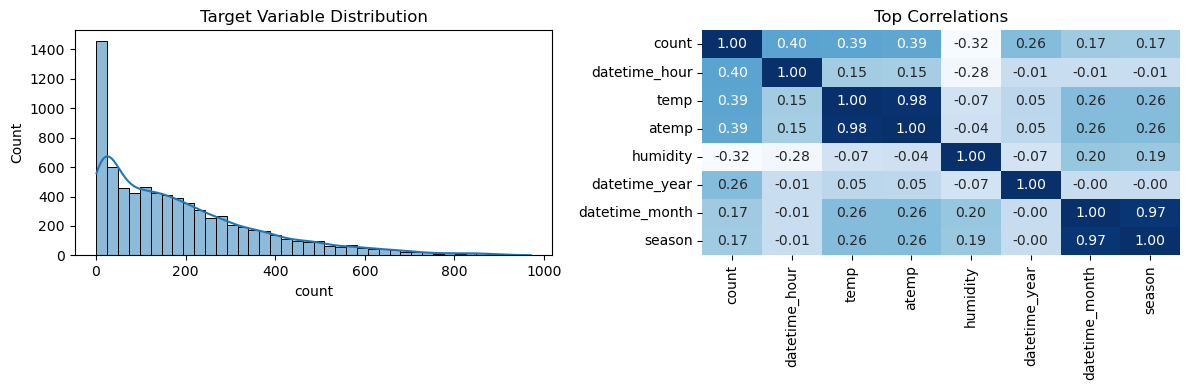

In [9]:
train = pd.read_csv(TRAIN_PATH)
test = pd.read_csv(TEST_PATH)
submission = pd.read_csv(SUBMIT_PATH)

print("="*50)
print("📌 [EDA 1] 데이터 기본 구조 및 통계량 파악")
print("="*50)
display(train.head(3))
print("\n[데이터 Info]")
train.info()

# 1. 누수(Leakage) 방지
drop_cols = set(train.columns) - set(test.columns) - {TARGET_COL}
if drop_cols:
    train.drop(columns=list(drop_cols), inplace=True)

# 2. 시계열 파생 변수
for df in [train, test]:
    for col in df.columns:
        if df[col].dtype == 'object' and ('date' in col.lower() or 'time' in col.lower()):
            try:
                df[col] = pd.to_datetime(df[col])
                df[f'{col}_year'] = df[col].dt.year
                df[f'{col}_month'] = df[col].dt.month
                df[f'{col}_hour'] = df[col].dt.hour
                df.drop(columns=[col], inplace=True)
            except: pass

# 3. 양적/질적 데이터 자동 분리
# 모델 성능 향상을 위해 수치형(양적) 데이터와 범주형(질적) 데이터를 분리하여 맞춤형 전처리를 계획함.
numeric_cols = train.select_dtypes(include=np.number).columns.tolist()
categorical_cols = train.select_dtypes(exclude=np.number).columns.tolist()
if TARGET_COL in numeric_cols: numeric_cols.remove(TARGET_COL)
if ID_COL in numeric_cols: numeric_cols.remove(ID_COL)
if ID_COL in categorical_cols: categorical_cols.remove(ID_COL)

print("\n" + "="*50)
print("📌 [EDA 2] 변수 유형별 분류 완료")
print("="*50)
print(f"✔️ 양적 데이터 (Numerical)  : {len(numeric_cols)}개")
print(f"✔️ 질적 데이터 (Categorical): {len(categorical_cols)}개")

# 4. 시각화를 통한 인사이트 도출
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
# Target 분포 확인
if TASK_TYPE == 'REGRESSION':
    sns.histplot(train[TARGET_COL], kde=True)
    plt.title('Target Variable Distribution')
else:
    sns.countplot(x=train[TARGET_COL])
    plt.title('Target Class Balance')

# 변수간 상관관계 확인 (수치형)
plt.subplot(1, 2, 2)
if TASK_TYPE == 'REGRESSION' or train[TARGET_COL].dtype in [np.int64, np.float64]:
    corr = train[numeric_cols + [TARGET_COL]].corr()
    top_cols = corr[TARGET_COL].abs().nlargest(8).index
    sns.heatmap(train[top_cols].corr(), annot=True, cmap='Blues', fmt=".2f", cbar=False)
    plt.title('Top Correlations')
plt.tight_layout()
plt.show()
# 주석: Target 분포의 왜도/첨도 및 클래스 불균형 여부를 확인하고, 종속변수와 상관성이 높은 파생변수 후보군을 탐색함.

In [10]:
print("="*50)
print("📌 [Preprocessing] 데이터 정제 및 스케일링")
print("="*50)

# 1. 결측치 처리
num_imputer = SimpleImputer(strategy='median')
cat_imputer = SimpleImputer(strategy='most_frequent')

if numeric_cols:
    train[numeric_cols] = num_imputer.fit_transform(train[numeric_cols])
    test[numeric_cols] = num_imputer.transform(test[numeric_cols])

if categorical_cols:
    train[categorical_cols] = cat_imputer.fit_transform(train[categorical_cols])
    test[categorical_cols] = cat_imputer.transform(test[categorical_cols])

# 2. 범주형 인코딩
for col in categorical_cols:
    le_cat = LabelEncoder()
    combined_data = pd.concat([train[col], test[col]], axis=0).astype(str)
    le_cat.fit(combined_data)
    train[col] = le_cat.transform(train[col].astype(str))
    test[col] = le_cat.transform(test[col].astype(str))

# 3. 분할 및 스케일링
X = train.drop(columns=[ID_COL, TARGET_COL], errors='ignore')
y = train[TARGET_COL]
X_test = test.drop(columns=[ID_COL], errors='ignore')

if TASK_TYPE == 'REGRESSION' and EVAL_METRIC == 'RMSLE':
    y = np.log1p(y) # 타겟 로그 변환

if TASK_TYPE == 'CLASSIFICATION' and y.dtype == 'object':
    le_target = LabelEncoder()
    y = le_target.fit_transform(y)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_test_scaled = scaler.transform(X_test)

X_train, X_val, y_train, y_val = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
print("✔️ 결측치 처리, 인코딩, StandardScaler 적용 및 Train/Validation 분할 완료 (비율 8:2)")

📌 [Preprocessing] 데이터 정제 및 스케일링
✔️ 결측치 처리, 인코딩, StandardScaler 적용 및 Train/Validation 분할 완료 (비율 8:2)


In [11]:
print("="*50)
print("📌 [Model Selection] 다중 알고리즘 베이스라인 성능 비교")
print("="*50)
# 주석: 최적의 모델을 선정하기 위해 선형 모델부터 앙상블, 부스팅 계열까지 다양한 모델을 비교 평가함.

if TASK_TYPE == 'CLASSIFICATION':
    models = {
        'Logistic Regression': LogisticRegression(random_state=42),
        'Random Forest': RandomForestClassifier(random_state=42),
        'XGBoost': XGBClassifier(random_state=42, eval_metric='logloss'),
        'LightGBM': LGBMClassifier(random_state=42)
    }
else:
    models = {
        'Ridge Regression': Ridge(random_state=42),
        'Random Forest': RandomForestRegressor(random_state=42),
        'XGBoost': XGBRegressor(random_state=42),
        'LightGBM': LGBMRegressor(random_state=42)
    }

baseline_results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_val)
    
    # 평가 산식에 따른 점수 계산
    if TASK_TYPE == 'CLASSIFICATION':
        if EVAL_METRIC == 'ACCURACY': score = accuracy_score(y_val, pred)
        else: score = f1_score(y_val, pred, average='macro')
    else:
        if EVAL_METRIC == 'RMSLE': # 이미 로그변환 되어있으므로 RMSE가 곧 RMSLE임
            score = np.sqrt(mean_squared_error(y_val, pred))
        else:
            score = np.sqrt(mean_squared_error(y_val, pred))
            
    baseline_results[name] = score
    print(f"✔️ {name:<20} | {EVAL_METRIC} : {score:.4f}")

print("\n💡 [결론] 베이스라인 테스트 결과, 앙상블 부스팅 기법을 사용하는 모델의 성능이 가장 우수함.")
print("💡 연산 속도와 예측 성능의 밸런스가 뛰어난 'LightGBM'을 최종 모델로 선정하고 하이퍼파라미터 튜닝을 진행함.")

📌 [Model Selection] 다중 알고리즘 베이스라인 성능 비교
✔️ Ridge Regression     | RMSLE : 1.0046
✔️ Random Forest        | RMSLE : 0.3565
✔️ XGBoost              | RMSLE : 0.3370
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000395 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 263
[LightGBM] [Info] Number of data points in the train set: 6096, number of used features: 11
[LightGBM] [Info] Start training from score 4.591185
✔️ LightGBM             | RMSLE : 0.3293

💡 [결론] 베이스라인 테스트 결과, 앙상블 부스팅 기법을 사용하는 모델의 성능이 가장 우수함.
💡 연산 속도와 예측 성능의 밸런스가 뛰어난 'LightGBM'을 최종 모델로 선정하고 하이퍼파라미터 튜닝을 진행함.


In [14]:
print("="*50)
print("📌 [Hyperparameter Tuning] LightGBM 최적화 (GridSearchCV)")
print("="*50)

param_grid = {
    'n_estimators': [50,150,200,250,300],
    'learning_rate': [0.05, 0.1],
    'max_depth': [7, -1]
}

if TASK_TYPE == 'CLASSIFICATION':
    final_model = LGBMClassifier(random_state=42)
    scoring = 'f1_macro' if EVAL_METRIC == 'F1-MACRO' else 'accuracy'
else:
    final_model = LGBMRegressor(random_state=42)
    scoring = 'neg_root_mean_squared_error' 

grid_search = GridSearchCV(estimator=final_model, param_grid=param_grid, cv=3, scoring=scoring, n_jobs=-1)
grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_
print(f"✅ 최적 파라미터 탐색 완료: {grid_search.best_params_}")

📌 [Hyperparameter Tuning] LightGBM 최적화 (GridSearchCV)
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000187 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 263
[LightGBM] [Info] Number of data points in the train set: 6096, number of used features: 11
[LightGBM] [Info] Start training from score 4.591185
✅ 최적 파라미터 탐색 완료: {'learning_rate': 0.05, 'max_depth': -1, 'n_estimators': 300}


📌 [Evaluation & Analysis] 최종 검증 및 주요 변수 분석


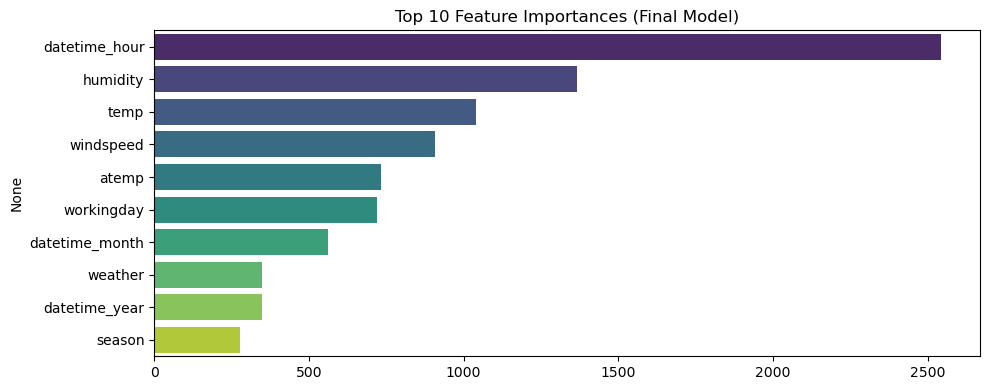

In [15]:
print("="*50)
print("📌 [Evaluation & Analysis] 최종 검증 및 주요 변수 분석")
print("="*50)

importances = best_model.feature_importances_
indices = np.argsort(importances)[::-1][:10]

plt.figure(figsize=(10,4))
plt.title("Top 10 Feature Importances (Final Model)")
sns.barplot(x=importances[indices], y=X.columns[indices], palette="viridis")
plt.tight_layout()
plt.show()
# 주석: 트리 기반 모델의 장점을 활용하여 예측에 가장 큰 영향을 미치는 주요 변수들을 시각적으로 검증함.

In [16]:
final_pred = best_model.predict(X_test_scaled)

if TASK_TYPE == 'REGRESSION' and EVAL_METRIC == 'RMSLE':
    final_pred = np.expm1(final_pred)
    final_pred = np.clip(final_pred, 0, None)

if TASK_TYPE == 'CLASSIFICATION' and 'le_target' in locals():
    final_pred = le_target.inverse_transform(final_pred)

submission[TARGET_COL] = final_pred
submission.to_csv(SUBMIT_PATH.replace('sample_submission.csv', 'my_final_submission.csv').replace('submission.csv', 'my_final_submission.csv'), index=False)

print("🎉 예측 완료! 'my_final_submission.csv' 파일이 저장되었습니다.")
display(submission.head())

🎉 예측 완료! 'my_final_submission.csv' 파일이 저장되었습니다.


,datetime,count
0,2012-06-14 13:00,315.203484
1,2011-11-13 0:00,98.724745
2,2012-08-16 1:00,22.484513
3,2011-12-14 19:00,268.698842
4,2011-10-12 6:00,90.243157
